# Implementasi Clustering untuk Menemukan Pola pada Data dengan Metodologi CRISP-DM

## Segmentasi Perilaku Pemegang Kartu Kredit dengan K-Means

**Sumber dataset:** Kaggle — https://www.kaggle.com/datasets/arjunbhasin2013/ccdata  
**Dataset:** `CC_GENERAL.csv`

Notebook ini mengikuti tahapan **CRISP-DM**: Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation, dan Deployment Preparation.


## 1. Business Understanding

### Latar Belakang
Data kartu kredit berisi informasi mengenai saldo, pembelian, transaksi tunai, pembayaran, limit kredit, frekuensi penggunaan, dan karakteristik pembayaran pelanggan. Data tersebut dapat digunakan untuk melakukan segmentasi pelanggan berdasarkan pola penggunaan kartu.

### Business Objective
Membentuk kelompok pelanggan dengan karakteristik perilaku penggunaan kartu kredit yang relatif mirip menggunakan algoritma **K-Means Clustering**.

### Data Mining Objective
- Menemukan kelompok pelanggan berdasarkan fitur numerik perilaku finansial.
- Membandingkan beberapa jumlah cluster menggunakan **Elbow Method** dan **Silhouette Score**.
- Membuat profil masing-masing cluster agar hasil clustering dapat diinterpretasikan.
- Menyiapkan model untuk deployment sehingga cluster pelanggan baru dapat diprediksi.

### Kesesuaian Dataset
Dataset sesuai untuk clustering karena berbentuk tabular, memiliki 8.950 baris dan 18 kolom, serta menyediakan banyak fitur numerik yang menggambarkan perilaku transaksi dan pembayaran pelanggan.


## 2. Data Understanding

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42
DATA_PATH = "CC_GENERAL.csv"

df = pd.read_csv(DATA_PATH)
print("Ukuran dataset:", df.shape)
display(df.head())


Ukuran dataset: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10000,1464.272089,0.799681,743.912685,222.365477,121.572742,120.837172,0.750381,0.278947,0.157972,0.035329,0,9,9864.750562,471.268289,369.843301,0.245246,12
1,C10001,1984.741913,0.818182,1065.323759,40.477815,249.173104,265.685933,0.892529,0.409348,0.598389,0.606188,3,8,5386.975657,2355.892995,766.881194,0.053375,12
2,C10002,1286.050906,0.868670,640.902058,315.378631,355.595560,218.984543,0.719271,0.217091,0.602511,0.265860,5,9,1537.325962,2364.124036,156.905375,0.099891,12
3,C10003,1151.549296,0.943682,233.303656,117.421888,153.394525,297.914224,0.334523,0.285790,0.193554,0.063837,0,9,766.598233,72.330221,406.465544,0.053825,12
4,C10004,2155.478731,0.914553,283.137269,45.577067,40.465268,1715.812252,0.536107,0.651658,0.239997,0.077853,3,8,892.155683,754.201991,356.901550,0.044036,12


In [2]:
print("Informasi dataset:")
df.info()

print("\nJumlah duplikat:", df.duplicated().sum())
print("\nJumlah missing value:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))


Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   

,missing
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [3]:
print("Statistik deskriptif:")
display(df.describe().T)

print("Jumlah nilai unik CUST_ID:", df["CUST_ID"].nunique())
print("Jumlah baris:", len(df))
print("Jumlah kolom:", df.shape[1])


Statistik deskriptif:


,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1403.768909,994.868152,9.903667,682.033044,1176.434797,1873.156874,10375.741730
BALANCE_FREQUENCY,8950.0,0.881191,0.117574,0.344986,0.803287,0.905655,1.000000,1.000000
PURCHASES,8950.0,746.190003,615.694127,0.657629,296.251255,582.431403,1025.553809,6157.026249
ONEOFF_PURCHASES,8950.0,362.408540,338.445757,0.501355,120.043513,262.796823,500.196209,4055.731739
INSTALLMENTS_PURCHASES,8950.0,240.771713,223.505171,0.138409,81.709098,175.078274,331.534127,1832.372296
CASH_ADVANCE,8950.0,398.754206,404.984709,0.032560,112.911439,270.431697,550.956676,4835.175733
PURCHASES_FREQUENCY,8950.0,0.502488,0.226635,0.004123,0.322405,0.499245,0.683585,0.991771
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.396812,0.201215,0.004817,0.237238,0.383828,0.540378,0.983008
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.400647,0.199323,0.004614,0.244131,0.383548,0.546519,0.967929
CASH_ADVANCE_FREQUENCY,8950.0,0.199892,0.164437,0.000018,0.068027,0.157227,0.292447,0.905245


Jumlah nilai unik CUST_ID: 8950
Jumlah baris: 8950
Jumlah kolom: 18


### Pemeriksaan awal

Dataset memiliki 8.950 observasi dan 18 kolom. `CUST_ID` merupakan identifier sehingga tidak digunakan sebagai fitur clustering. Kolom numerik lainnya dapat digunakan untuk menggambarkan perilaku pelanggan.

Pada data yang digunakan, pemeriksaan missing value dan duplikasi dilakukan sebelum preprocessing.


## 3. Data Preparation

Tahapan persiapan data:
1. Memilih secara spesifik 3 fitur numerik utama untuk clustering: `BALANCE`, `PURCHASES`, dan `CREDIT_LIMIT`.
2. Menggunakan median imputation sebagai langkah pengamanan terhadap missing value pada fitur-fitur terpilih.
3. Melakukan standardisasi dengan `StandardScaler` agar fitur dengan skala besar tidak mendominasi perhitungan jarak K-Means.
4. Tidak menggunakan variabel target karena clustering merupakan metode unsupervised learning.

In [4]:
feature_cols = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT']
X = df[feature_cols].copy()

print("Jumlah fitur untuk clustering:", len(feature_cols))
print(feature_cols)

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_scaled = preprocessor.fit_transform(X)
print("Shape data setelah preprocessing:", X_scaled.shape)

Jumlah fitur untuk clustering: 3
['BALANCE', 'PURCHASES', 'CREDIT_LIMIT']
Shape data setelah preprocessing: (8950, 3)


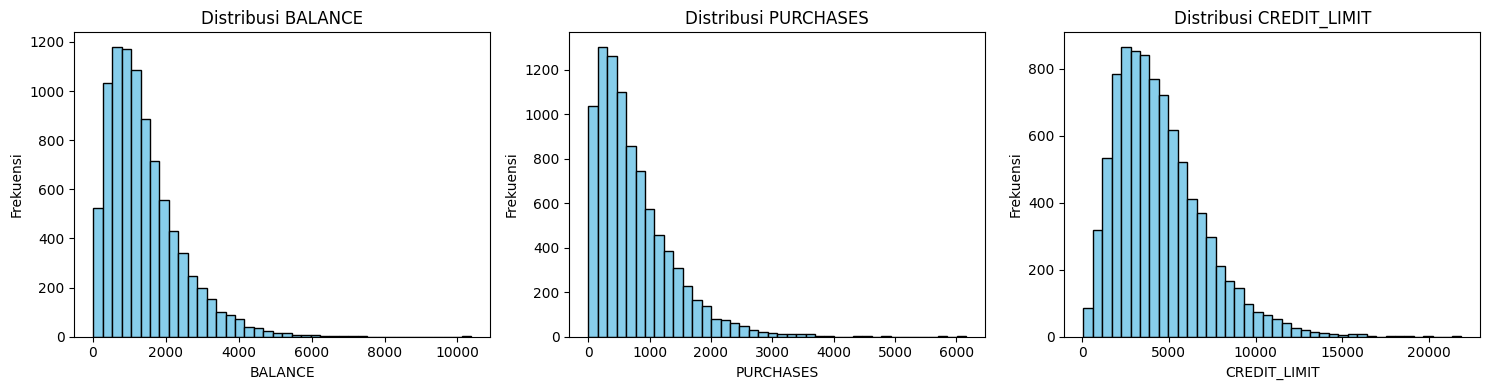

In [14]:
# Melihat distribusi 3 fitur utama yang digunakan untuk clustering
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, feature_cols):
    ax.hist(df[col], bins=40, color='skyblue', edgecolor='black')
    ax.set_title(f"Distribusi {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frekuensi")
plt.tight_layout()
plt.show()

## 4. Modeling

Algoritma yang digunakan adalah **K-Means Clustering**. K-Means mengelompokkan observasi berdasarkan kedekatannya terhadap centroid.

Jumlah cluster diuji dari **K=2 sampai K=10**. Dua metrik digunakan:
- **Inertia** untuk Elbow Method; semakin kecil semakin baik, tetapi penurunan mulai melandai dapat menjadi indikasi jumlah K yang wajar.
- **Silhouette Score**; semakin mendekati 1 menunjukkan pemisahan cluster yang lebih jelas.


In [6]:
results = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    results.append({
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette Score": score
    })

evaluation_df = pd.DataFrame(results)
display(evaluation_df)


,K,Inertia,Silhouette Score
0,2,21021.139468,0.291103
1,3,16093.715818,0.301081
2,4,11867.555902,0.317615
3,5,10595.160437,0.262682
4,6,9510.337938,0.259771
5,7,8531.435592,0.257011
6,8,7884.837555,0.257118
7,9,7349.514606,0.258059
8,10,6862.188714,0.259206


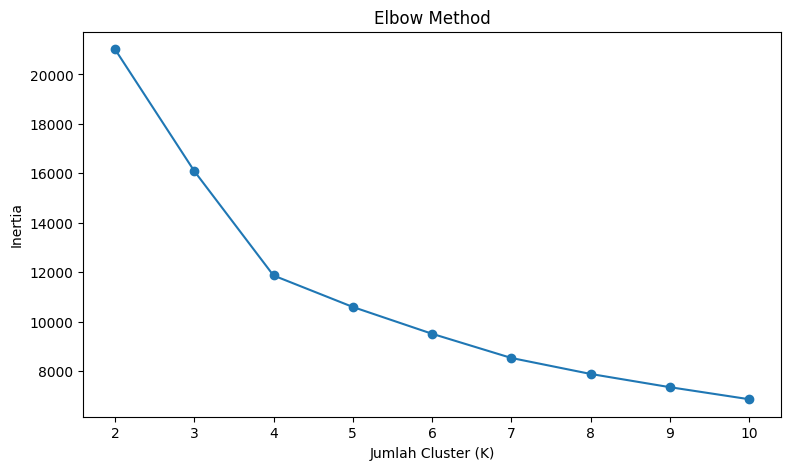

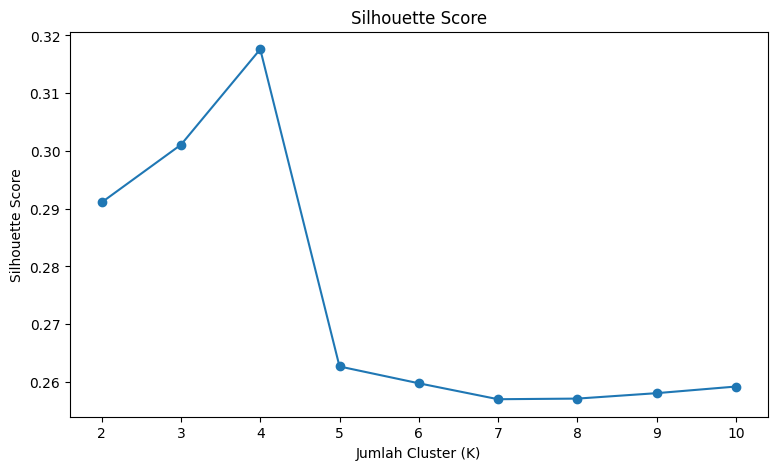

K dengan Silhouette Score tertinggi: 4


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(evaluation_df["K"], evaluation_df["Inertia"], marker="o")
ax.set_title("Elbow Method")
ax.set_xlabel("Jumlah Cluster (K)")
ax.set_ylabel("Inertia")
ax.set_xticks(evaluation_df["K"])
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(evaluation_df["K"], evaluation_df["Silhouette Score"], marker="o")
ax.set_title("Silhouette Score")
ax.set_xlabel("Jumlah Cluster (K)")
ax.set_ylabel("Silhouette Score")
ax.set_xticks(evaluation_df["K"])
plt.show()

best_k_silhouette = int(evaluation_df.loc[evaluation_df["Silhouette Score"].idxmax(), "K"])
print("K dengan Silhouette Score tertinggi:", best_k_silhouette)


### Pemilihan jumlah cluster

Berdasarkan evaluasi menggunakan 3 fitur utama pada dataset ini, **K=4 memiliki Silhouette Score tertinggi** (~0.3176) dibandingkan jumlah cluster lainnya.

Oleh karena itu, model final ditetapkan menggunakan **4 cluster** untuk mendapatkan segmentasi perilaku pelanggan yang paling terpisah dan optimal secara matematis.

In [8]:
FINAL_K = best_k_silhouette

kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=20
)

cluster_labels = kmeans.fit_predict(X_scaled)
df_result = df.copy()
df_result["Cluster"] = cluster_labels

print("Ukuran masing-masing cluster:")
display(df_result["Cluster"].value_counts().sort_index().to_frame("Jumlah Pelanggan"))

final_silhouette = silhouette_score(X_scaled, cluster_labels)
print("Final Silhouette Score:", round(final_silhouette, 4))
print("Final Inertia:", round(kmeans.inertia_, 2))


Ukuran masing-masing cluster:


,Jumlah Pelanggan
Cluster,
0,1826
1,1467
2,1535
3,4122


Final Silhouette Score: 0.3176
Final Inertia: 11867.56


## 5. Evaluation & Interpretation

Untuk membantu interpretasi, rata-rata fitur numerik dibandingkan antar-cluster. Nilai rata-rata digunakan sebagai ringkasan karakteristik, bukan sebagai label absolut terhadap setiap pelanggan.


In [9]:
cluster_profile = df_result.groupby("Cluster")[feature_cols].mean().T
display(cluster_profile.round(2))


Cluster,0,1,2,3
BALANCE,1133.11,1196.63,3046.45,985.67
PURCHASES,592.02,1785.07,640.97,483.94
CREDIT_LIMIT,8137.10,3995.24,4014.62,3207.21


In [15]:
# Profil ringkas pada 3 indikator utama yang digunakan
profile_summary = df_result.groupby("Cluster")[feature_cols].mean().round(2)
display(profile_summary)

,BALANCE,PURCHASES,CREDIT_LIMIT
Cluster,,,
0,1133.11,592.02,8137.10
1,1196.63,1785.07,3995.24
2,3046.45,640.97,4014.62
3,985.67,483.94,3207.21


In [16]:
# Analisis komparatif untuk membantu profiling 4 cluster berdasarkan 3 fitur utama
summary_stats = df_result.groupby("Cluster")[feature_cols].mean().T
display(summary_stats.style.background_gradient(cmap='coolwarm', axis=1))

Cluster,0,1,2,3
BALANCE,1133.110024,1196.628957,3046.447072,985.667612
PURCHASES,592.017665,1785.067439,640.968426,483.938816
CREDIT_LIMIT,8137.102139,3995.241495,4014.624334,3207.205590


### Interpretasi dan Profiling Cluster

1. **Cluster 0: Pengguna dengan Limit Kredit Tinggi (High Credit Limit - Moderate Activity)**
   - **Karakteristik**: Memiliki rata-rata limit kredit (`CREDIT_LIMIT`) tertinggi secara signifikan (8.137 USD), dibarengi dengan saldo utang (`BALANCE`) yang tergolong sedang (1.133 USD) dan tingkat belanja (`PURCHASES`) yang moderat (592 USD).
   - **Kecenderungan Perilaku**: Kelompok nasabah yang memiliki fasilitas kredit besar namun secara rata-rata tidak menggunakannya secara agresif, baik untuk berutang maupun untuk berbelanja.

2. **Cluster 1: Pengguna dengan Aktivitas Belanja Tinggi (High Spenders)**
   - **Karakteristik**: Memiliki rata-rata transaksi belanja (`PURCHASES`) tertinggi (1.785 USD) di antara semua kelompok, dengan limit kredit rata-rata menengah (3.995 USD) dan saldo utang yang terjaga di angka sedang (1.196 USD).
   - **Kecenderungan Perilaku**: Kelompok nasabah yang aktif menggunakan kartu kredit sebagai alat pembayaran utama untuk transaksi belanja harian atau ritel.

3. **Cluster 2: Pengguna dengan Saldo Utang Tinggi (High Balance - Low Spenders)**
   - **Karakteristik**: Mencatatkan rata-rata saldo utang berjalan (`BALANCE`) tertinggi (3.046 USD) meskipun limit kredit mereka sedang (4.014 USD). Di sisi lain, rata-rata transaksi belanja baru mereka relatif rendah (640 USD).
   - **Kecenderungan Perilaku**: Kelompok nasabah yang cenderung mempertahankan atau membawa saldo utang cukup besar dari bulan ke bulan, dengan aktivitas penambahan transaksi baru yang minimal.

4. **Cluster 3: Pengguna Kartu Kredit Skala Rendah (Low-end / Value Users)**
   - **Karakteristik**: Memiliki rata-rata terkecil pada ketiga dimensi: saldo utang terendah (985 USD), aktivitas belanja terendah (483 USD), dan alokasi limit kredit paling kecil (3.207 USD).
   - **Kecenderungan Perilaku**: Kelompok nasabah dengan penggunaan kartu kredit yang sangat terbatas, baik karena faktor kebutuhan transaksi yang minimal maupun batas limit yang relatif rendah.

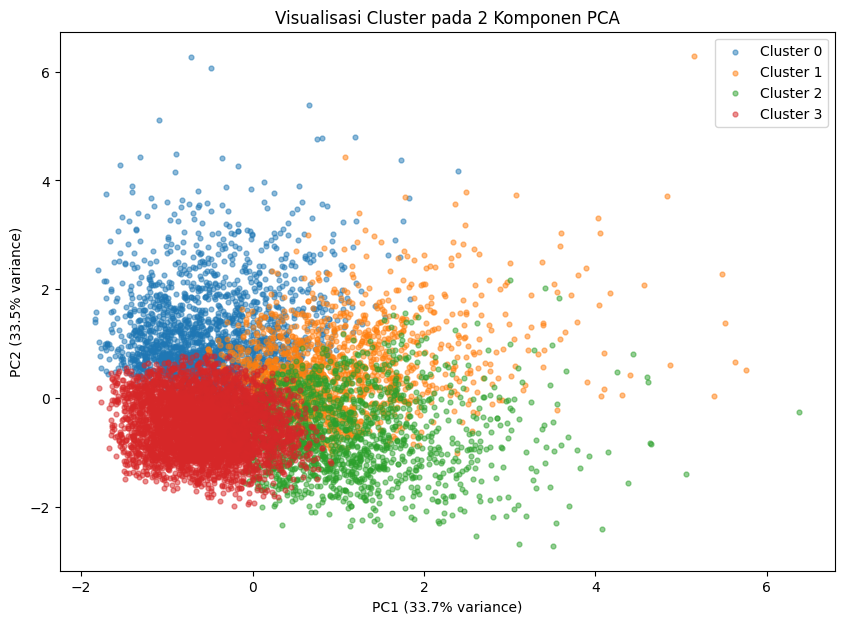

Total variance yang dijelaskan oleh 2 komponen PCA: 67.22 %


In [12]:
# Visualisasi 2D menggunakan PCA untuk membantu melihat struktur cluster
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": cluster_labels.astype(str)
})

fig, ax = plt.subplots(figsize=(10, 7))
for cluster in sorted(plot_df["Cluster"].unique()):
    part = plot_df[plot_df["Cluster"] == cluster]
    ax.scatter(part["PC1"], part["PC2"], s=12, alpha=0.5, label=f"Cluster {cluster}")
ax.set_title("Visualisasi Cluster pada 2 Komponen PCA")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.legend()
plt.show()

print("Total variance yang dijelaskan oleh 2 komponen PCA:",
      round(pca.explained_variance_ratio_.sum()*100, 2), "%")


### Kesimpulan Evaluation

- K-Means berhasil membagi pelanggan menjadi **4 kelompok** (cluster) berdasarkan kombinasi 3 fitur finansial utama.
- Silhouette Score (0.3176) menunjukkan adanya peningkatan batas pemisahan cluster yang lebih baik setelah menyederhanakan dimensi analisis menjadi hanya 3 fitur terpilih.
- Penamaan dan pemprofilan segmen sepenuhnya didasarkan pada karakteristik statistik deskriptif dari ketiga fitur utama tersebut (`BALANCE`, `PURCHASES`, dan `CREDIT_LIMIT`).

## 6. Deployment Preparation

Model deployment terdiri dari:
- preprocessing (`median imputation` + `StandardScaler`)
- K-Means dengan jumlah cluster hasil evaluasi
- daftar fitur yang sama dengan saat training

Pipeline disimpan menggunakan `joblib` agar dapat digunakan oleh aplikasi Streamlit.


In [13]:
import joblib

deployment_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=20))
])

deployment_pipeline.fit(df[feature_cols])

os.makedirs("model", exist_ok=True)
joblib.dump(
    {
        "pipeline": deployment_pipeline,
        "features": feature_cols,
        "final_k": FINAL_K
    },
    "model/kmeans_pipeline.joblib"
)

cluster_profile.to_csv("model/cluster_profile.csv")

print("Model deployment berhasil disimpan.")
print("File: model/kmeans_pipeline.joblib")


Model deployment berhasil disimpan.
File: model/kmeans_pipeline.joblib


## 7. Ringkasan CRISP-DM

| Tahap | Hasil |
|---|---|
| Business Understanding | Segmentasi pelanggan kartu kredit berdasarkan pola penggunaan |
| Data Understanding | 8.950 baris, 18 kolom, identifier `CUST_ID`, serta analisis difokuskan pada 3 fitur numerik terpilih |
| Data Preparation | Imputasi median dan standardisasi fitur (`BALANCE`, `PURCHASES`, `CREDIT_LIMIT`) |
| Modeling | K-Means Clustering |
| Evaluation | K diuji 2–10 menggunakan Elbow dan Silhouette (K=4 terpilih sebagai yang terbaik) |
| Final Model | K dipilih berdasarkan Silhouette Score tertinggi (K=4) |
| Deployment | Pipeline model disimpan untuk digunakan oleh Streamlit |